In [ ]:
# Change working dir
import os
os.chdir("../")

In [18]:
# Imports
import cv2
from modules.inference.model import Detector
from modules.inference.nms import NMS
from modules.utils.metrics import match_detections, calculate_precision_recall_curve, calculate_map_x_point_interpolated

# Parameters
WEIGHTS_PATH = 'storage/yolo_model_1/yolov4-tiny-logistics_size_416_1.weights'
CONFIG_PATH = "storage/yolo_model_1/yolov4-tiny-logistics_size_416_1.cfg"
CLASS_NAMES_PATH = "storage/yolo_model_1/logistics.names"

SCORE_THRESHOLD = 0.5
IOU_THRESHOLD = 0.4
NUM_CLASSES = 20

print('DONE')

DONE


In [19]:
# Match jpg files to txt files
dataset_path = 'storage/logistics/'
files = os.listdir(dataset_path)

image_key = {}
for file in files:
    suffix = file[-4:]
    if suffix == '.jpg':
        image_key[file] = file[:-4] + '.txt'

In [20]:
# Get GT data from txt files
gt_boxes = []
gt_classes = []
sizes = []

for jpg, txt in image_key.items():

    # Get frame dimmensions
    frame = cv2.imread(dataset_path + jpg)
    sizes.append(frame.shape[:2])

    # Read GT data 
    with open(dataset_path + txt, 'r') as f:
        b_list = []
        c_list = []
        for line in f:
            data = [float(n) for n in line.strip('\n').split(' ')]
            b_list.append(data[1:])
            c_list.append(int(data[0]))

    # Save GT data
    gt_boxes.append(b_list)
    gt_classes.append(c_list)

def convert_box_coords(detection, img_height, img_width):
    x_center_raw = detection[0] * img_width # 230.976
    y_center_raw = detection[1] * img_height # 243
    width_raw = int(detection[2] * img_width) # 328
    height_raw = int(detection[3] * img_height) # 486
    x_left = int(x_center_raw - (width_raw / 2))
    y_top = int(y_center_raw - (height_raw / 2))
    return [x_left, y_top, width_raw, height_raw]

# Convert frame coords to proper values
converted_gt_boxes = []
for i in range(len(gt_boxes)):
    boxes = []
    for detection in gt_boxes[i]:

        # Get frame dimmensions
        img_height = sizes[i][0]
        img_width = sizes[i][1]

        # Convert box coords
        converted_box = convert_box_coords(detection, img_height, img_width)
        boxes.append(converted_box)

    converted_gt_boxes.append(boxes)

gt_boxes = converted_gt_boxes

In [21]:
# Initialize model and nms 
model = Detector(WEIGHTS_PATH, CONFIG_PATH, CLASS_NAMES_PATH, SCORE_THRESHOLD)
nms = NMS(SCORE_THRESHOLD, IOU_THRESHOLD)

# Gather predictions
boxes = []
classes = []
scores = []
cls_scores = []

count = 0
for image in image_key:

    # Get frame
    frame = cv2.imread(dataset_path + image)

    # Run YOLO model and filter out low confidence detection boxes 
    output = model.predict(frame)
    bboxes, class_ids, confidence_scores, class_scores = model.post_process(output)

    # Supress boxes using NMS
    filtered_bboxes, filtered_class_ids, filtered_scores, filtered_class_scores = nms.filter(bboxes, class_ids, confidence_scores, class_scores)

    # Save predictions
    boxes.append(filtered_bboxes)
    classes.append(filtered_class_ids)
    scores.append(filtered_scores)
    cls_scores.append(filtered_class_scores)

    # Increment
    count += 1
    print(f'{count}/{len(image_key)}')


1/9525
2/9525
3/9525
4/9525
5/9525
6/9525
7/9525
8/9525
9/9525
10/9525
11/9525
12/9525
13/9525
14/9525
15/9525
16/9525
17/9525
18/9525
19/9525
20/9525
21/9525
22/9525
23/9525
24/9525
25/9525
26/9525
27/9525
28/9525
29/9525
30/9525
31/9525
32/9525
33/9525
34/9525
35/9525
36/9525
37/9525
38/9525
39/9525
40/9525
41/9525
42/9525
43/9525
44/9525
45/9525
46/9525
47/9525
48/9525
49/9525
50/9525
51/9525
52/9525
53/9525
54/9525
55/9525
56/9525
57/9525
58/9525
59/9525
60/9525
61/9525
62/9525
63/9525
64/9525
65/9525
66/9525
67/9525
68/9525
69/9525
70/9525
71/9525
72/9525
73/9525
74/9525
75/9525
76/9525
77/9525
78/9525
79/9525
80/9525
81/9525
82/9525
83/9525
84/9525
85/9525
86/9525
87/9525
88/9525
89/9525
90/9525
91/9525
92/9525
93/9525
94/9525
95/9525
96/9525
97/9525
98/9525
99/9525
100/9525
101/9525
102/9525
103/9525
104/9525
105/9525
106/9525
107/9525
108/9525
109/9525
110/9525
111/9525
112/9525
113/9525
114/9525
115/9525
116/9525
117/9525
118/9525
119/9525
120/9525
121/9525
122/9525
123/9525
1

In [22]:
y_true, pred_scores = match_detections(
    boxes,         # Detected bounding boxes per image
    classes,       # Detected class labels per image
    scores,        # Detection confidence scores per image
    cls_scores,    # Classification score vectors per image
    gt_boxes,      # Ground truth bounding boxes per image
    gt_classes,    # Ground truth class labels per image
    IOU_THRESHOLD  # IoU threshold for a valid match
) 

# Print the evaluation results: true labels and corresponding prediction scores.
print("True labels:", y_true)
print("Prediction scores:", pred_scores)

True labels: [16, -1, 16, 16, 17, -1, 1, 1, 1, 1, 1, 14, 3, 18, 17, 14, 14, 14, 7, 10, 10, 7, 10, 7, 10, 10, 7, 10, 19, 17, 17, 13, 7, -1, 10, 10, 10, 7, 7, 10, 10, 10, 13, 12, 8, 8, 19, -1, 19, -1, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 1, 1, 4, -1, -1, 5, 16, 16, 10, 10, 10, 10, 10, 10, 7, 7, 7, -1, 7, -1, -1, 10, 7, 7, 7, 10, 10, 7, -1, 0, 11, 4, 4, 4, 4, 14, 14, 10, 10, -1, 10, -1, 10, 10, 13, 10, 13, 13, 13, 13, 10, 7, 10, 10, 2, 2, 14, 16, -1, 16, 16, 10, 7, 10, 17, 17, 1, 10, -1, 1, 1, 1, 1, 16, 10, 10, 10, 10, 1, 1, 1, -1, 14, 14, 8, 10, 8, 10, 8, 8, 4, 12, 18, 17, 1, 1, 3, 4, 10, 10, 7, 7, 7, -1, -1, 10, 10, 10, 10, -1, 7, 13, 13, 7, 10, 10, 10, -1, 10, 13, 10, 10, 10, 10, 10, 10, 10, 10, 3, 3, 3, 3, 2, -1, 14, 1, -1, 2, 2, 2, 2, -1, 2, 2, 2, 2, 2, 2, 

In [23]:
# Calculate the precision-recall curve based on the true labels and prediction scores.
# This function returns dictionaries containing precision, recall, and threshold values for each class.
precision, recall, thresholds = calculate_precision_recall_curve(
    y_true,         # True labels from the evaluation
    pred_scores,    # Predicted scores from the evaluation
    num_classes=NUM_CLASSES  # Number of classes
)

# For each class, print the precision, recall, and threshold values.
for cls in range(NUM_CLASSES):
    print(f"\nClass {cls}:")
    print("Precision:", precision[cls])
    print("Recall:", recall[cls])
    print("Thresholds:", thresholds[cls])

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



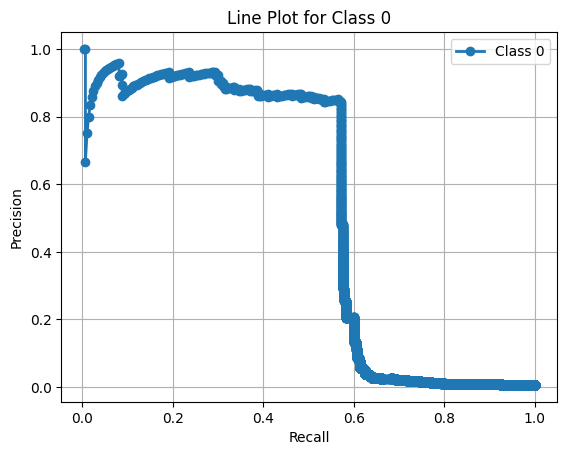

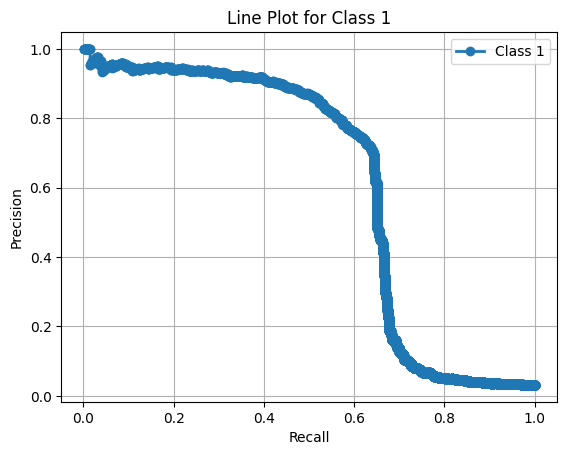

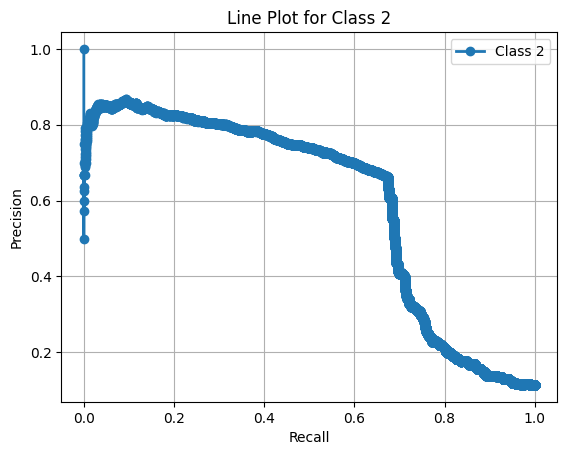

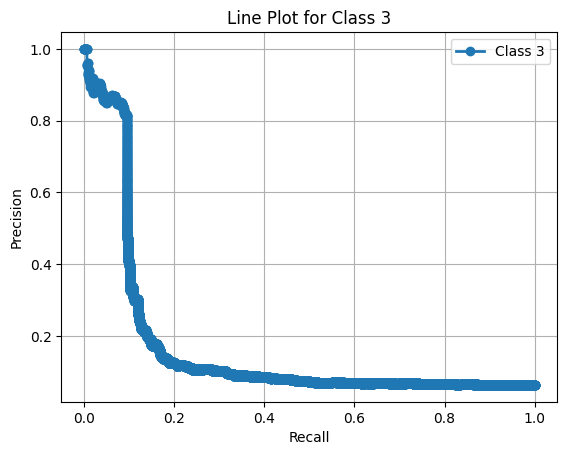

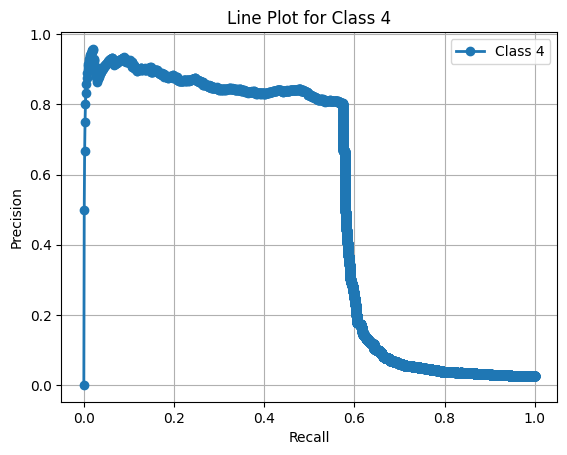

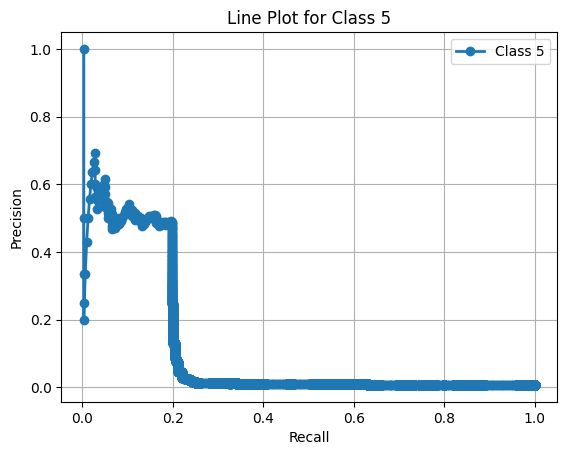

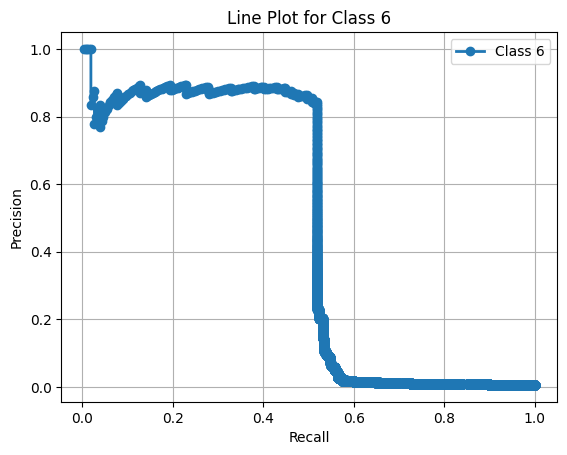

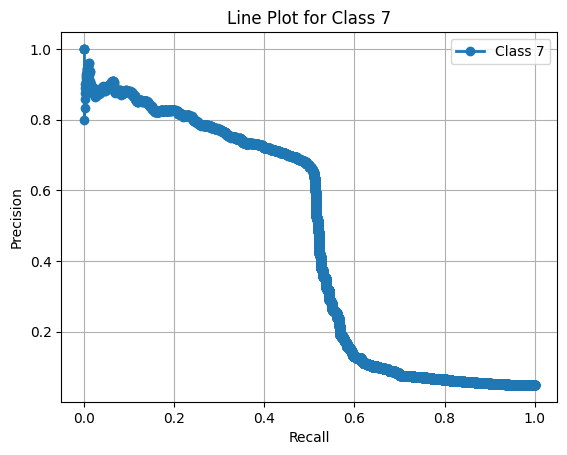

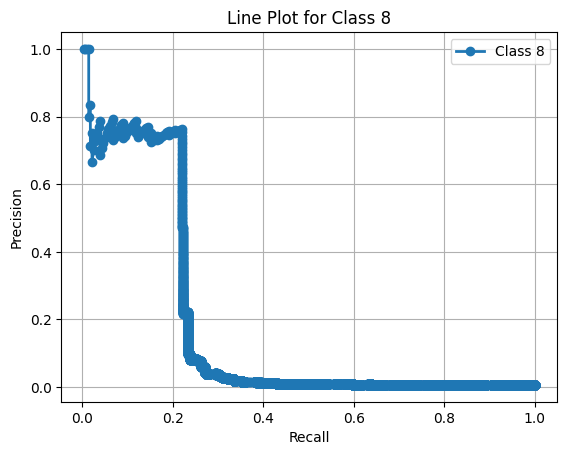

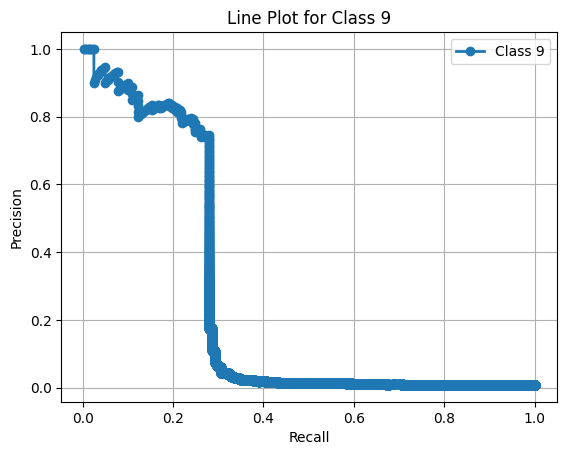

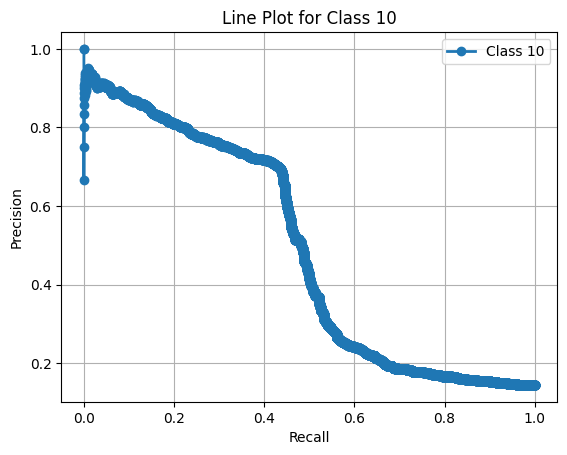

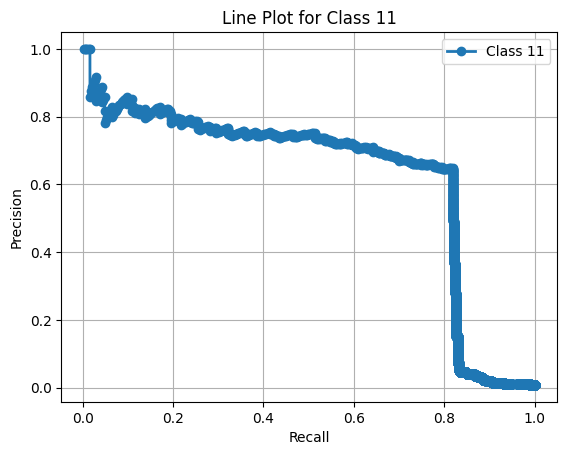

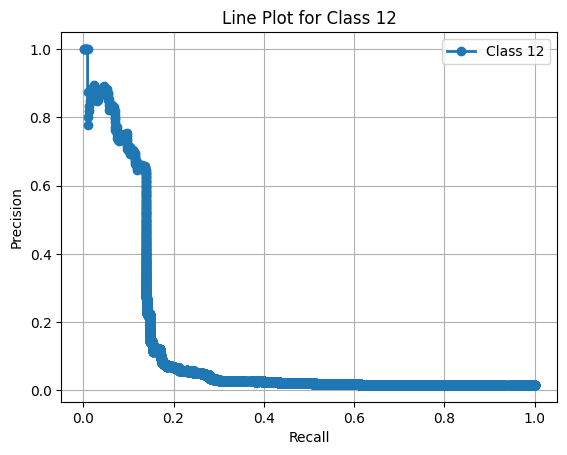

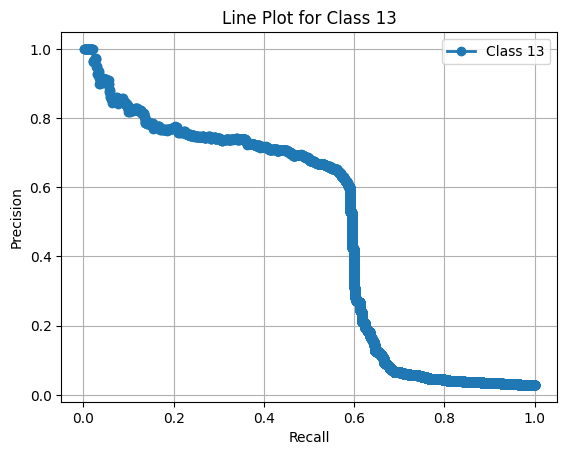

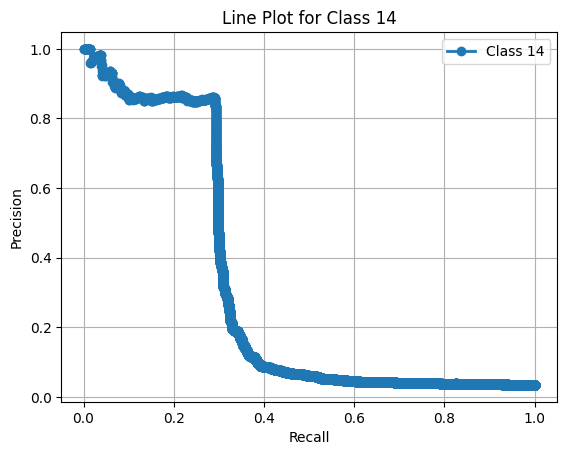

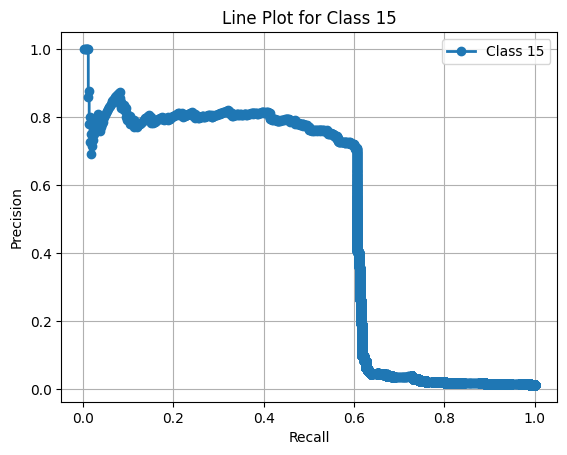

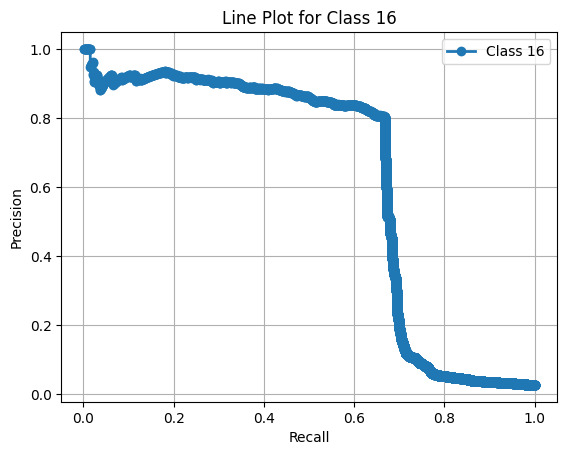

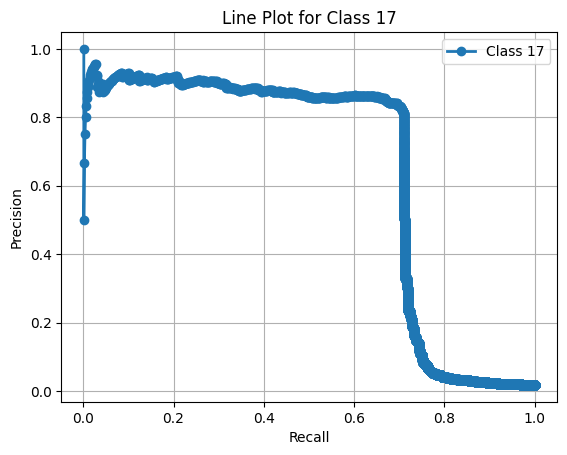

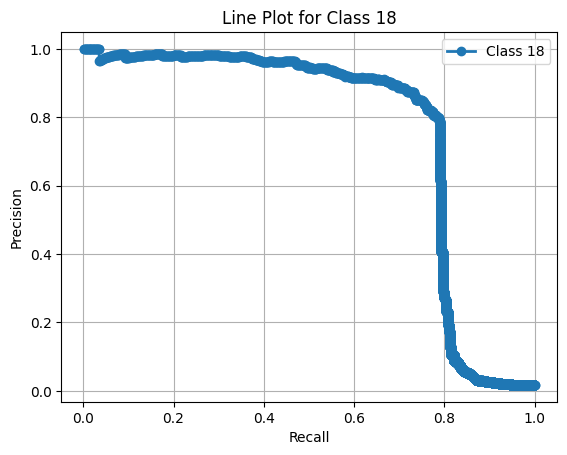

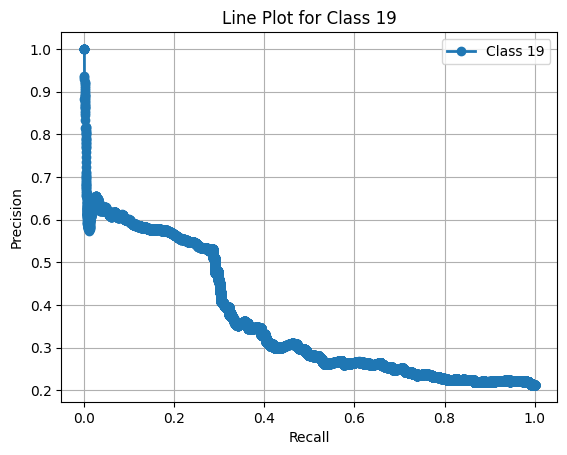

In [24]:
# Combine the precision and recall values into (recall, precision) pairs for each class.
precision_recall_points = {
    class_index: list(zip(recall[class_index], precision[class_index]))
    for class_index in range(NUM_CLASSES)
}

### CHART HERE?? ###
# precision_recall_points

import matplotlib.pyplot as plt

# Create a line plot for each class
for cls, points in precision_recall_points.items():
    x, y = zip(*points)
    plt.figure()
    plt.plot(x, y, marker='o', linestyle='-', linewidth=2, label=f"Class {cls}")
    plt.title(f"Line Plot for Class {cls}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"analysis/model1_curves/prec-recal-curve_class-{cls}.png", dpi=300, bbox_inches='tight')
    plt.show()


In [25]:
# Compute the Mean Average Precision (mAP) using 11-point interpolation.
# The function calculates the average precision for each class by interpolating precision
# at 11 recall levels, and then averages these values to obtain the mAP.
map_value = calculate_map_x_point_interpolated(precision_recall_points, NUM_CLASSES)

# Output the calculated mAP value formatted to four decimal places.
print(f"Mean Average Precision (mAP): {map_value:.4f}")

Mean Average Precision (mAP): 0.4557


In [53]:
import pandas as pd 

data = {
    'Metric': ['mAP'],
    'Model 1': [0.2870],
    'Model 2': [0.2782],
}

df = pd.DataFrame(data)
df

# df.to_csv('model_comparison.csv', index=False)


,Metric,Model 1,Model 2
0,mAP,0.287,0.2782
